In [1]:
# Cell 1: Import Libraries & Load Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load data
df = pd.read_csv('border_intrusion.csv')
features = df.columns.tolist()
X = df.values

# K-Means algorithm from scratch
def kmeans(X, k, dist_func, max_iter=100):
    np.random.seed(42)
    centroids = X[np.random.choice(len(X), k, replace=False)]
    for _ in range(max_iter):
        distances = np.array([dist_func(X, c) for c in centroids]).T
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

# Silhouette score from scratch
def silhouette(X, labels, dist_func):
    n = len(X)
    silhouette_vals = []
    for i in range(n):
        same_cluster = X[labels == labels[i]]
        a = np.mean(dist_func(same_cluster, X[i])) if len(same_cluster) > 1 else 0
        b_vals = []
        for k in np.unique(labels):
            if k != labels[i]:
                other_cluster = X[labels == k]
                b_vals.append(np.mean(dist_func(other_cluster, X[i])))
        b = min(b_vals) if b_vals else 0
        silhouette_vals.append((b - a) / max(a, b) if max(a, b) > 0 else 0)
    return np.mean(silhouette_vals)

print(f"✓ Loaded {len(df)} samples with {len(features)} features")
print(f"✓ Features: {features}")

✓ Loaded 1999 samples with 6 features
✓ Features: ['entry_angle', 'speed', 'speed_variance', 'stop_duration', 'time_of_intrusion', 'path_deviation']


In [2]:



# Cell 2: Normalize & Define Distance Functions
means, stds = np.mean(X, axis=0), np.std(X, axis=0)
X_norm = (X - means) / stds  # Z-Score normalization

def euclidean(a, b): return np.sqrt(np.sum((a - b) ** 2, axis=-1))
def manhattan(a, b): return np.sum(np.abs(a - b), axis=-1)
def chebyshev(a, b): return np.max(np.abs(a - b), axis=-1)
DIST_FUNCS = {'euclidean': euclidean, 'manhattan': manhattan, 'chebyshev': chebyshev}
print("✓ Data normalized | Distance functions: Euclidean, Manhattan, Chebyshev")

✓ Data normalized | Distance functions: Euclidean, Manhattan, Chebyshev


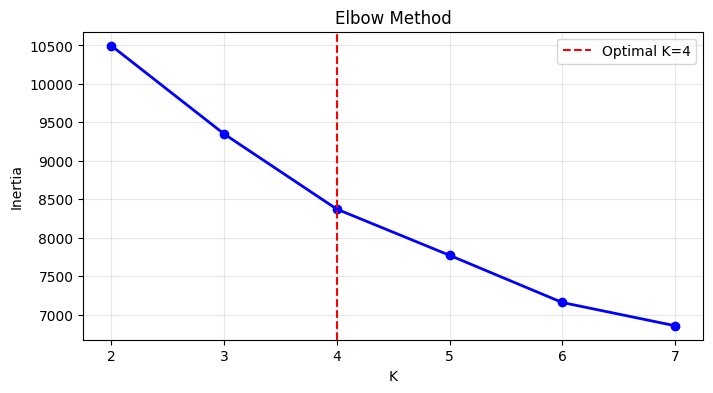

✓ Optimal K = 4


In [7]:
inertias = []
for k in range(2, 8):
    labels, centroids = kmeans(X_norm, k, euclidean)
    inertias.append(sum(np.sum((X_norm[labels==i] - centroids[i])**2) for i in range(k)))

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), inertias, 'bo-', linewidth=2)
plt.axvline(x=4, color='r', linestyle='--', label='Optimal K=4')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('elbow_scratch.png', dpi=100); plt.show()
print("✓ Optimal K = 4")

In [12]:
# Cell 5: Run K-Means (K=4) for All Distance Metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, accuracy_score
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

K = 4
results = {}

# Get reference labels from sklearn KMeans
sklearn_kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
true_labels = sklearn_kmeans.fit_predict(X_norm)

# Function to align cluster labels for accuracy calculation
def align_labels(true_labels, pred_labels, k):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=range(k))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping.get(l, l) for l in pred_labels])

print("=" * 80)
print("CLUSTERING RESULTS (K=4)")
print("=" * 80)
print(f"{'Metric':<12} | {'Silhouette':>10} | {'Accuracy':>10}")
print("-" * 80)
for name, func in DIST_FUNCS.items():
    labels, centroids = kmeans(X_norm, K, func)
    sil = silhouette_score(X_norm, labels)
    # Align labels and calculate accuracy using sklearn accuracy_score
    aligned_labels = align_labels(true_labels, labels, K)
    acc =round(accuracy_score(true_labels, aligned_labels) * 100, 2)
    results[name] = {'labels': labels, 'centroids': centroids.tolist(), 'silhouette': round(sil, 4), 'accuracy': acc}
    print(f"{name.upper():<12} | {sil:>10.4f} | {acc:>9.2f}%")

CLUSTERING RESULTS (K=4)
Metric       | Silhouette |   Accuracy
--------------------------------------------------------------------------------
EUCLIDEAN    |     0.1381 |     96.25%
MANHATTAN    |     0.1247 |     69.13%
CHEBYSHEV    |     0.0356 |     58.73%


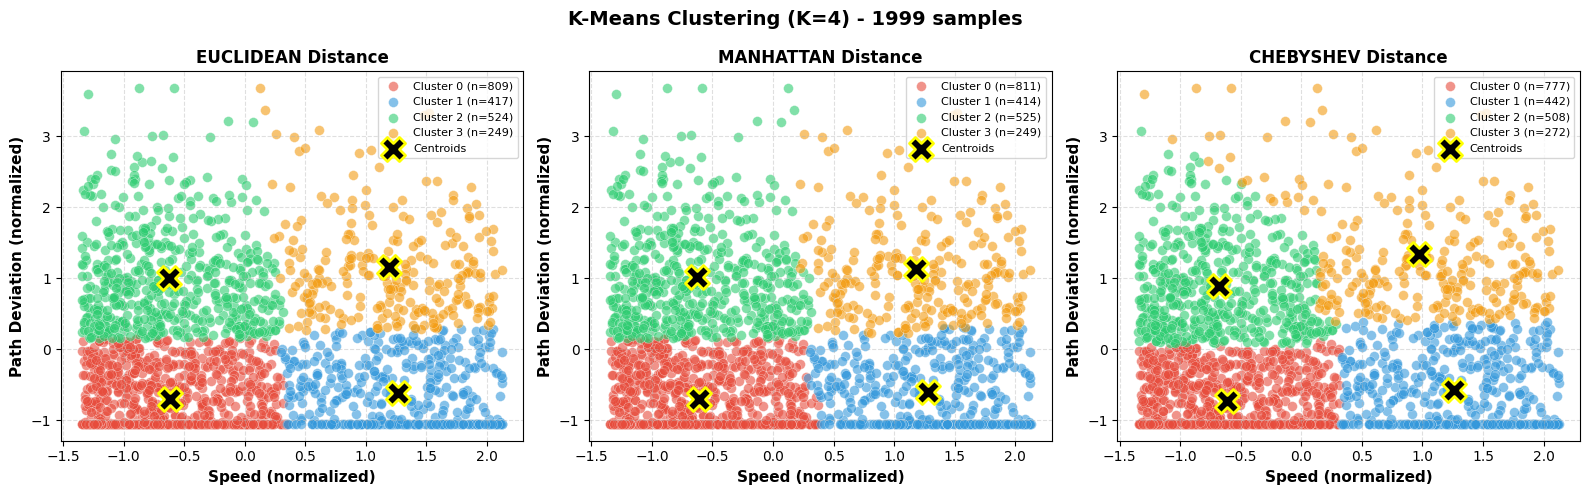

✓ Features used: ['speed', 'path_deviation']
✓ Total samples: 1999
✓ Saved: clustering_2d_map.png


In [13]:
# Cell 6: 2D Clustering using 2 Key Features (speed & path_deviation)

key_features = ['speed', 'path_deviation']
feat_idx = [features.index(f) for f in key_features]
X_2d = X_norm[:, feat_idx]

# Re-run K-Means on 2D data
results_2d = {}
for name, func in DIST_FUNCS.items():
    labels, centroids = kmeans(X_2d, K, func)
    results_2d[name] = {'labels': labels, 'centroids': centroids}

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (name, data) in enumerate(results_2d.items()):
    ax = axes[idx]
    labels = data['labels']
    centroids = data['centroids']
    
    # Plot each cluster with circles
    for cluster_id in range(K):
        mask = (labels == cluster_id)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                   c=colors[cluster_id], marker='o',
                   label=f'Cluster {cluster_id} (n={np.sum(mask)})',
                   alpha=0.6, s=50, edgecolors='white', linewidth=0.3)
    
    # Plot centroids with X marker
    ax.scatter(centroids[:, 0], centroids[:, 1], 
               c='black', marker='X', s=300, edgecolors='yellow', linewidth=2,
               label='Centroids', zorder=10)
    
    ax.set_xlabel('Speed (normalized)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Path Deviation (normalized)', fontsize=11, fontweight='bold')
    ax.set_title(f'{name.upper()} Distance', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.4, linestyle='--')

plt.suptitle(f'K-Means Clustering (K={K}) - {len(X_2d)} samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_2d_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Features used: {key_features}")
print(f"✓ Total samples: {len(X_2d)}")
print(f"✓ Saved: clustering_2d_map.png")

In [14]:
# Cell 7: Save Results for Flask Web App
output = {
    'scaler_mean': means.tolist(), 
    'scaler_scale': stds.tolist(), 
    'k': K, 
    'features': features
}
for name, data in results.items():
    output[name] = {
        'centroids': data['centroids'], 
        'accuracy': data['accuracy']
    }

with open('model_results_scratch.json', 'w') as f:
    json.dump(output, f, indent=2)

print("✓ Saved: model_results_scratch.json")
print("\nAccuracy Scores:")
for name, data in results.items():
    print(f"  {name.upper()}: {data['accuracy']}%")

✓ Saved: model_results_scratch.json

Accuracy Scores:
  EUCLIDEAN: 96.25%
  MANHATTAN: 69.13%
  CHEBYSHEV: 58.73%
